# 03 – Continuous Distributions

Author: Joe  
Project: AI Foundations – Probability & Statistics

This notebook introduces some key **continuous probability distributions** and how to work with them.

We will look at:

- Probability density functions (pdf) and cumulative distribution functions (cdf)
- Uniform distribution
- Exponential distribution
- Normal distribution

As usual, the plan is:
- understand the story behind each distribution,
- write down the formulas,
- and then verify intuition with simulation and plots.

## Contents
1. [Setup](#1-setup)
2. [PDFs and CDFs](#2-pdfs-and-cdfs)
3. [Uniform Distribution](#3-uniform-distribution)
4. [Exponential Distribution](#4-exponential-distribution)
5. [Normal Distribution](#5-normal-distribution)
6. [Standardisation and Z-scores](#6-standardisation-and-z-scores)
7. [Practice / TODOs](#7-practice--todos)


## 1. Setup

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

np.set_printoptions(precision=4, suppress=True)

---
## 2. PDFs and CDFs

For a continuous random variable $X$:

- The **probability density function (pdf)** $f_X(x)$ satisfies
  - $f_X(x) \ge 0$ for all $x$
  - $\int_{-\infty}^{\infty} f_X(x) \, dx = 1$

- The **cumulative distribution function (cdf)** is
  $$F_X(x) = P(X \le x) = \int_{-\infty}^{x} f_X(t) \, dt.$$

For continuous distributions we have:
- $P(a \le X \le b) = \int_a^b f_X(x) \, dx$
- $P(X = x) = 0$ for any specific point $x$

So individual points have zero probability; only intervals matter.

---
## 3. Uniform Distribution

**Story:** All values in an interval are equally likely.

Let $X \sim \text{Uniform}(a,b)$ with $a < b$.

**PDF:**
\begin{equation}
f_X(x) = \begin{cases}
\dfrac{1}{b-a}, & a \le x \le b, \\
0, & \text{otherwise.}
\end{cases}
\end{equation}

**CDF:**
\begin{equation}
F_X(x) = P(X \le x) = \begin{cases}
0, & x < a, \\
\dfrac{x-a}{b-a}, & a \le x \le b, \\
1, & x > b.
\end{cases}
\end{equation}

**Mean and variance:**
- $\mathbb{E}[X] = \dfrac{a + b}{2}$
- $\text{Var}(X) = \dfrac{(b-a)^2}{12}$

In [2]:
# Sample from Uniform(a,b) and compare empirical mean/variance
a, b = 2.0, 5.0
samples_unif = np.random.uniform(a, b, size=100000)

mean_emp = samples_unif.mean()
var_emp = samples_unif.var(ddof=1)

mean_theory = 0.5 * (a + b)
var_theory = (b - a) ** 2 / 12

mean_emp, mean_theory, var_emp, var_theory

(np.float64(3.502972046363658), 3.5, np.float64(0.7457932015022434), 0.75)

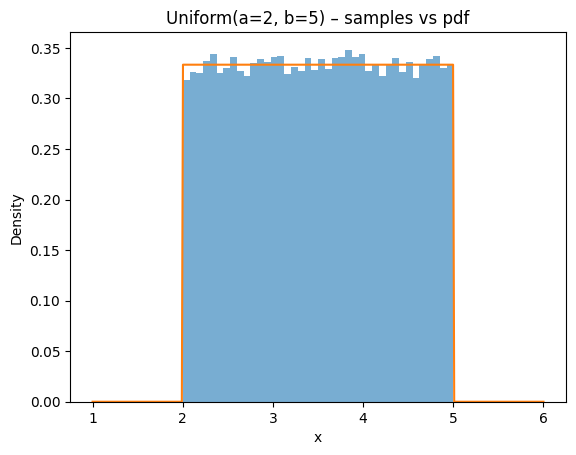

In [3]:
# Plot histogram of Uniform(a,b) samples and overlay theoretical pdf
x_vals = np.linspace(a - 1, b + 1, 400)
pdf_vals = np.where((x_vals >= a) & (x_vals <= b), 1.0 / (b - a), 0.0)

plt.hist(samples_unif, bins=40, density=True, alpha=0.6)
plt.plot(x_vals, pdf_vals)
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Uniform(a=2, b=5) – samples vs pdf')
plt.show()

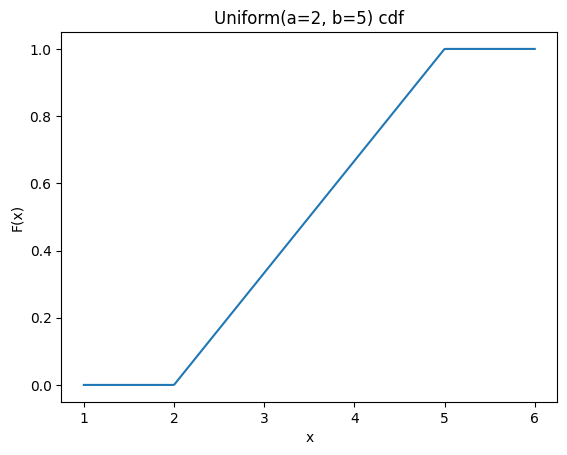

In [4]:
# Visualise the cdf for Uniform(a,b)
x_vals = np.linspace(a - 1, b + 1, 400)
cdf_vals = np.piecewise(
    x_vals,
    [x_vals < a, (x_vals >= a) & (x_vals <= b), x_vals > b],
    [0.0, lambda x: (x - a) / (b - a), 1.0],
)

plt.plot(x_vals, cdf_vals)
plt.xlabel('x')
plt.ylabel('F(x)')
plt.title('Uniform(a=2, b=5) cdf')
plt.ylim(-0.05, 1.05)
plt.show()

---
## 4. Exponential Distribution

**Story:** Models waiting times between events in a Poisson process.
Examples: time between arrivals in a queue, time until a component fails (under certain assumptions).

Let $X \sim \text{Exponential}(\lambda)$ with rate $\lambda > 0$.

**PDF:**
\begin{equation}
f_X(x) = \begin{cases}
\lambda e^{-\lambda x}, & x \ge 0, \\
0, & x < 0.
\end{cases}
\end{equation}

**CDF:**
\begin{equation}
F_X(x) = P(X \le x) = \begin{cases}
0, & x < 0, \\
1 - e^{-\lambda x}, & x \ge 0.
\end{cases}
\end{equation}

**Mean and variance:**
- $\mathbb{E}[X] = \dfrac{1}{\lambda}$
- $\text{Var}(X) = \dfrac{1}{\lambda^2}$

A famous property: the exponential distribution is **memoryless**:
$P(X > s + t \mid X > s) = P(X > t)$ for $s,t \ge 0$.

In [5]:
# Sample from Exponential(lambda) and compare empirical mean/variance
lam = 2.0  # rate
samples_exp = np.random.exponential(scale=1/lam, size=100000)

mean_emp = samples_exp.mean()
var_emp = samples_exp.var(ddof=1)

mean_theory = 1 / lam
var_theory = 1 / (lam ** 2)

mean_emp, mean_theory, var_emp, var_theory

(np.float64(0.5017935661786167), 0.5, np.float64(0.2506320375077856), 0.25)

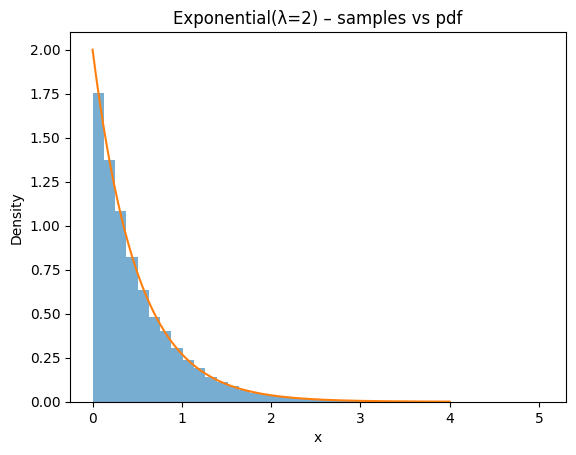

In [6]:
# Plot histogram of Exponential(lambda) samples and overlay theoretical pdf
x_vals = np.linspace(0, 4, 400)
pdf_vals = lam * np.exp(-lam * x_vals)

plt.hist(samples_exp, bins=40, density=True, alpha=0.6)
plt.plot(x_vals, pdf_vals)
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Exponential(λ=2) – samples vs pdf')
plt.show()

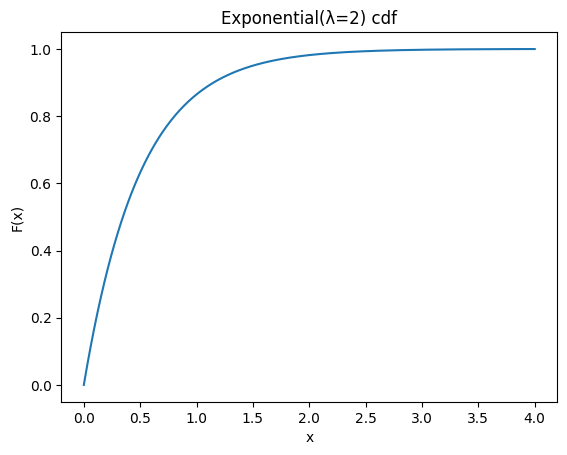

In [7]:
# Plot cdf of Exponential(lambda)
x_vals = np.linspace(0, 4, 400)
cdf_vals = 1 - np.exp(-lam * x_vals)

plt.plot(x_vals, cdf_vals)
plt.xlabel('x')
plt.ylabel('F(x)')
plt.title('Exponential(λ=2) cdf')
plt.ylim(-0.05, 1.05)
plt.show()

---
## 5. Normal Distribution

**Story:** The normal distribution shows up everywhere: measurement errors, heights, averages of many
small effects. It is central to the **Central Limit Theorem**.

Let $X \sim \mathcal{N}(\mu, \sigma^2)$.

**PDF:**
\begin{equation}
f_X(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(x-\mu)^2}{2\sigma^2} \right).
\end{equation}

**Mean and variance:**
- $\mathbb{E}[X] = \mu$
- $\text{Var}(X) = \sigma^2$

Special case: the **standard normal** $Z \sim \mathcal{N}(0,1)$.
In practice we often convert a general normal variable $X$ to a standard normal Z-score.

In [8]:
# Sample from Normal(mu, sigma^2) and compare empirical mean/variance
mu = 5.0
sigma = 2.0
samples_norm = np.random.normal(loc=mu, scale=sigma, size=100000)

mean_emp = samples_norm.mean()
var_emp = samples_norm.var(ddof=1)

mean_theory = mu
var_theory = sigma ** 2

mean_emp, mean_theory, var_emp, var_theory

(np.float64(5.0122741270587206), 5.0, np.float64(3.994280217297863), 4.0)

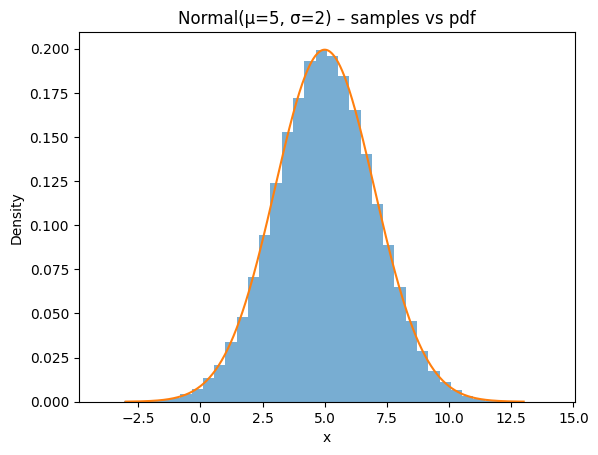

In [9]:
# Plot histogram of Normal(mu, sigma^2) samples and overlay theoretical pdf
x_vals = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
pdf_vals = (1 / (math.sqrt(2 * math.pi) * sigma)) * np.exp(-(x_vals - mu) ** 2 / (2 * sigma ** 2))

plt.hist(samples_norm, bins=40, density=True, alpha=0.6)
plt.plot(x_vals, pdf_vals)
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Normal(μ=5, σ=2) – samples vs pdf')
plt.show()

---
## 6. Standardisation and Z-scores

For a normal random variable $X \sim \mathcal{N}(\mu, \sigma^2)$, the **standardised** variable
$Z$ is defined by
\begin{equation}
Z = \frac{X - \mu}{\sigma}.
\end{equation}

If $X$ is normal, then $Z \sim \mathcal{N}(0,1)$.

In statistics, Z-scores tell you how many standard deviations above or below the mean a value lies.

Example: if exam scores follow $\mathcal{N}(60, 10^2)$ and you score 75, your Z-score is
$z = (75 - 60)/10 = 1.5$ (one and a half standard deviations above the mean).

In [10]:
# Demonstrate standardisation numerically
mu = 60
sigma = 10
samples_exam = np.random.normal(loc=mu, scale=sigma, size=100000)

z_scores = (samples_exam - mu) / sigma

z_mean_emp = z_scores.mean()
z_var_emp = z_scores.var(ddof=1)

z_mean_emp, z_var_emp  # should be close to 0 and 1

(np.float64(0.0015739109833367764), np.float64(0.994224319954655))

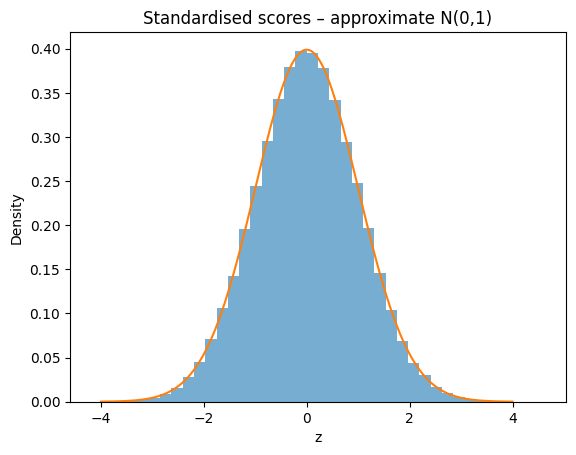

In [11]:
# Histogram of z-scores (approximate standard normal)
plt.hist(z_scores, bins=40, density=True, alpha=0.6)

x_vals = np.linspace(-4, 4, 400)
pdf_std = (1 / math.sqrt(2 * math.pi)) * np.exp(-x_vals ** 2 / 2)
plt.plot(x_vals, pdf_std)

plt.xlabel('z')
plt.ylabel('Density')
plt.title('Standardised scores – approximate N(0,1)')
plt.show()

---
## 7. Practice / TODOs

### 7.1 Suggested exercises

- **Uniform**
  - Compute probabilities like $P(2.5 \le X \le 4)$ for $X \sim \text{Uniform}(2,5)$.
  - Check results by simulation.

- **Exponential**
  - For $X \sim \text{Exponential}(\lambda)$, compute $P(X > t)$ and relate it to the memoryless property.
  - Example: with $\lambda = 2$, find $P(X > 1)$ and compare with empirical frequency.

- **Normal**
  - Standardise raw values to Z-scores.
  - Use Z-scores to approximate probabilities (for example $P(X > x_0)$) using tables or software.

### 7.2 Template for worked examples

Use this pattern to drop in questions from your course.

Example (markdown):

Question: Let $X \sim \text{Uniform}(2,5)$. Find $P(3 \le X \le 4)$.

Solution (theory):
$P(3 \le X \le 4) = (4-3)/(5-2) = 1/3$.

Example (code):

```python
a, b = 2.0, 5.0
theory = (4 - 3) / (b - a)
samples = np.random.uniform(a, b, size=100000)
empirical = np.mean((samples >= 3) & (samples <= 4))
theory, empirical
```

Fill this notebook with concrete problems from MATH4002 so it becomes your personal reference for continuous distributions.